118 images × 39209 neurons
Standardizing neural responses...
Fitting full logistic regression...
Full model fitted.
||w_full|| = 0.3769756561399722
Running parallel LOO fits...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:  2.5min
[Parallel(n_jobs=-1)]: Done  13 tasks      | elapsed:  2.6min
[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:  2.8min
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:  5.2min
[Parallel(n_jobs=-1)]: Done  50 tasks      | elapsed:  7.5min
[Parallel(n_jobs=-1)]: Done  65 tasks      | elapsed:  7.8min
[Parallel(n_jobs=-1)]: Done  83 out of 118 | elapsed: 10.3min remaining:  4.4min
[Parallel(n_jobs=-1)]: Done  95 out of 118 | elapsed: 10.7min remaining:  2.6min
[Parallel(n_jobs=-1)]: Done 107 out of 118 | elapsed: 12.6min remaining:  1.3min
[Parallel(n_jobs=-1)]: Done 118 out of 118 | elapsed: 12.7min finished


LOO fits complete.
W shape: (118, 39209)

Field stability vs full model:
Mean cosine: 0.9958099924849269
Std cosine : 0.003508441191299579
Min cosine : 0.9839139816407515
Mean ||w|| drift: -0.0008767650971521603
Running PCA on LOO fields...

LOO field PCA:
Top-10 explained variance ratios: [0.0335 0.0329 0.0297 0.0272 0.0258 0.0249 0.0241 0.0229 0.0207 0.0201]
Cumulative variance @10: 0.2617962
Effective dimension: 41.867820739746094


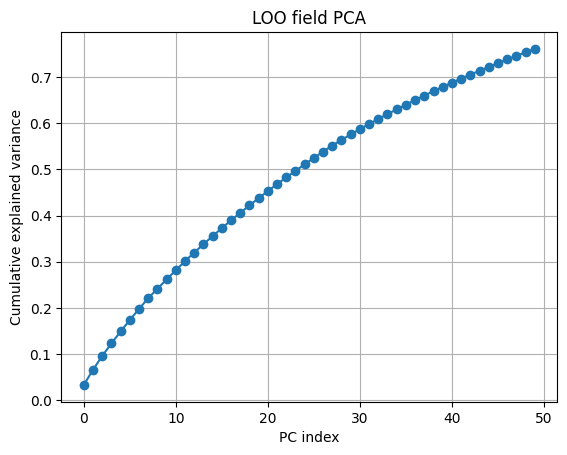

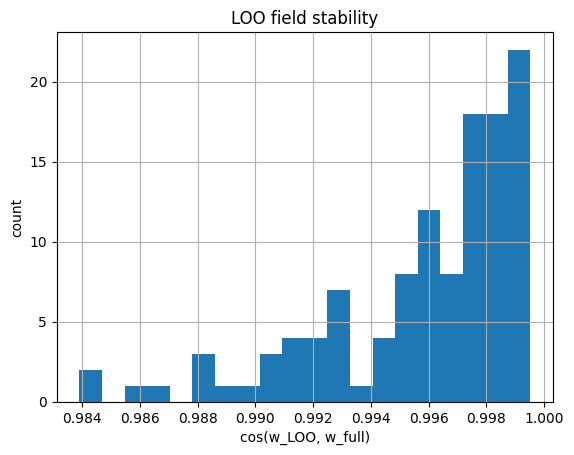

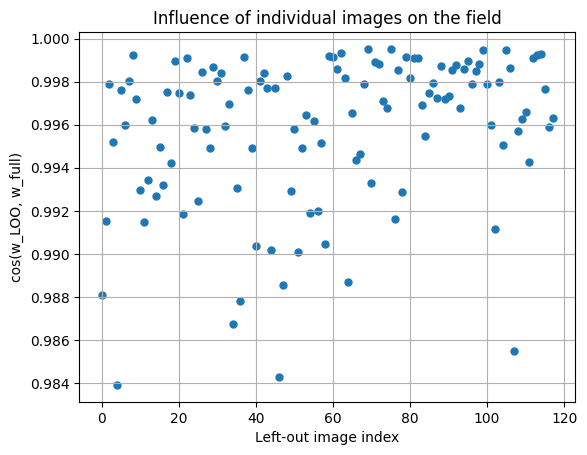


Done.


In [ ]:
"""
Variance geometry diagnostics for large neural populations
Animate vs Inanimate decoding (ImageNet labels)

LOO logistic regression fields
PCA of field variability
Safe for ~20k–40k neurons (no NxN covariance matrices)
"""

import numpy as np
import matplotlib.pyplot as plt

from joblib import Parallel, delayed
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

# ============================================================
# PATHS
# ============================================================

VIT_PATH    = '/home/maria/ProjectionSort/data/google_vit-base-patch16-224_embeddings_logits.pkl'
NEURAL_PATH = '/home/maria/ProjectionSort/data/hybrid_neural_responses_reduced.npy'
AREAS_PATH  = '/home/maria/ProjectionSort/data/brain_area.npy'

# ============================================================
# LOAD DATA
# ============================================================

vit   = np.load(VIT_PATH, allow_pickle=True)['natural_scenes']   # (images, 1000)
R     = np.load(NEURAL_PATH).T                                   # (images, neurons)
areas = np.load(AREAS_PATH, allow_pickle=True)

n_images, n_neurons = R.shape
print(f"{n_images} images × {n_neurons} neurons")

# ============================================================
# IMAGE-NET ANIMATE / INANIMATE LABEL
# ============================================================

top1 = np.argmax(vit, axis=1)
y = (top1 <= 397).astype(int)   # 1 = animate, 0 = inanimate

# ============================================================
# STANDARDIZE NEURAL RESPONSES
# ============================================================

print("Standardizing neural responses...")
scaler = StandardScaler(with_mean=True, with_std=True)
X = scaler.fit_transform(R).astype(np.float32)

# ============================================================
# LOGISTIC REGRESSION FACTORY
# ============================================================

def make_lr(C=1.0):
    return LogisticRegression(
        penalty="l2",
        C=C,
        solver="saga",
        max_iter=5000,
        tol=1e-4,
        fit_intercept=True,
        n_jobs=1,      # IMPORTANT: avoid nested parallelism
        random_state=0,
    )

# ============================================================
# FULL MODEL (REFERENCE FIELD)
# ============================================================

print("Fitting full logistic regression...")
lr_full = make_lr(C=1.0)
lr_full.fit(X, y)

w_full = lr_full.coef_.ravel().astype(np.float64)
b_full = float(lr_full.intercept_[0])

print("Full model fitted.")
print("||w_full|| =", np.linalg.norm(w_full))

# ============================================================
# LOO WORKER
# ============================================================

def fit_loo(i, X, y, C=1.0):
    mask = np.ones(len(y), dtype=bool)
    mask[i] = False

    lr = make_lr(C=C)
    lr.fit(X[mask], y[mask])

    w = lr.coef_.ravel().astype(np.float32)
    b = float(lr.intercept_[0])

    return w, b

# ============================================================
# PARALLEL LOO FITS
# ============================================================

print("Running parallel LOO fits...")

results = Parallel(
    n_jobs=-1,
    verbose=10,
    backend="loky"
)(
    delayed(fit_loo)(i, X, y, 1.0)
    for i in range(n_images)
)

W = np.stack([r[0] for r in results], axis=0)   # (images, neurons)
B = np.array([r[1] for r in results], dtype=np.float32)

print("LOO fits complete.")
print("W shape:", W.shape)

# ============================================================
# STABILITY METRICS
# ============================================================

def cosine(a, b, eps=1e-12):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + eps)

cos_to_full = np.array([
    cosine(W[i].astype(np.float64), w_full)
    for i in range(n_images)
])

norm_full = np.linalg.norm(w_full)
norm_loo  = np.linalg.norm(W.astype(np.float64), axis=1)

print("\nField stability vs full model:")
print("Mean cosine:", cos_to_full.mean())
print("Std cosine :", cos_to_full.std())
print("Min cosine :", cos_to_full.min())
print("Mean ||w|| drift:", (norm_loo - norm_full).mean())

# ============================================================
# PCA ON LOO FIELDS
# ============================================================

print("Running PCA on LOO fields...")

Wc = W - W.mean(axis=0, keepdims=True)

kmax = min(n_images - 1, 50)
pca = PCA(n_components=kmax, svd_solver="randomized", random_state=0)
Z = pca.fit_transform(Wc)

expl = pca.explained_variance_ratio_
eig  = pca.explained_variance_

# Participation ratio (effective dimension)
d_eff = (eig.sum() ** 2) / (np.square(eig).sum() + 1e-12)

print("\nLOO field PCA:")
print("Top-10 explained variance ratios:", np.round(expl[:10], 4))
print("Cumulative variance @10:", expl[:10].sum())
print("Effective dimension:", float(d_eff))

# ============================================================
# DIAGNOSTIC PLOTS
# ============================================================

plt.figure()
plt.plot(np.cumsum(expl), marker='o')
plt.xlabel("PC index")
plt.ylabel("Cumulative explained variance")
plt.title("LOO field PCA")
plt.grid(True)
plt.show()

plt.figure()
plt.hist(cos_to_full, bins=20)
plt.xlabel("cos(w_LOO, w_full)")
plt.ylabel("count")
plt.title("LOO field stability")
plt.grid(True)
plt.show()

plt.figure()
plt.scatter(np.arange(n_images), cos_to_full, s=25)
plt.xlabel("Left-out image index")
plt.ylabel("cos(w_LOO, w_full)")
plt.title("Influence of individual images on the field")
plt.grid(True)
plt.show()

print("\nDone.")


Projection stats:
Mean proj: 0.3745272936621618
Std proj : 0.002607942124817319
Min proj : 0.36561231352701284
Full proj: 0.37697565613997236


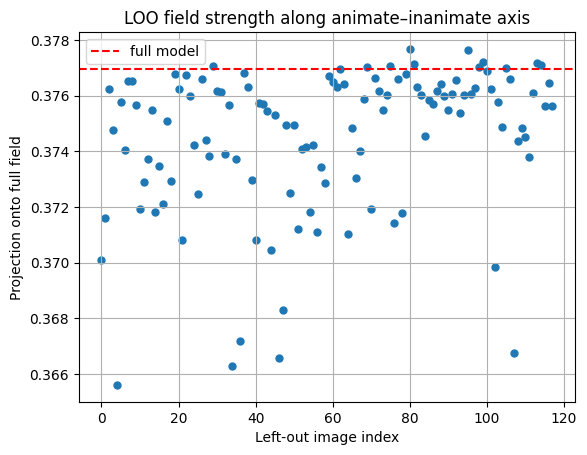

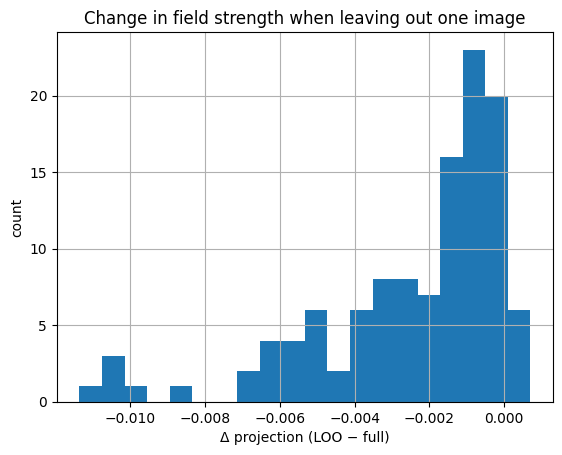

In [3]:
# ============================================================
# PROJECTION ONTO FULL FIELD DIRECTION
# ============================================================

w0 = w_full / np.linalg.norm(w_full)   # unit semantic axis

proj = np.array([
    np.dot(W[i], w0)
    for i in range(n_images)
])

proj_full = np.dot(w_full, w0)  # = ||w_full||

print("Projection stats:")
print("Mean proj:", proj.mean())
print("Std proj :", proj.std())
print("Min proj :", proj.min())
print("Full proj:", proj_full)

# ============================================================
# PLOTS
# ============================================================

plt.figure()
plt.scatter(np.arange(n_images), proj, s=25)
plt.axhline(proj_full, color='red', linestyle='--', label='full model')
plt.xlabel("Left-out image index")
plt.ylabel("Projection onto full field")
plt.title("LOO field strength along animate–inanimate axis")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.hist(proj - proj_full, bins=20)
plt.xlabel("Δ projection (LOO − full)")
plt.ylabel("count")
plt.title("Change in field strength when leaving out one image")
plt.grid(True)
plt.show()


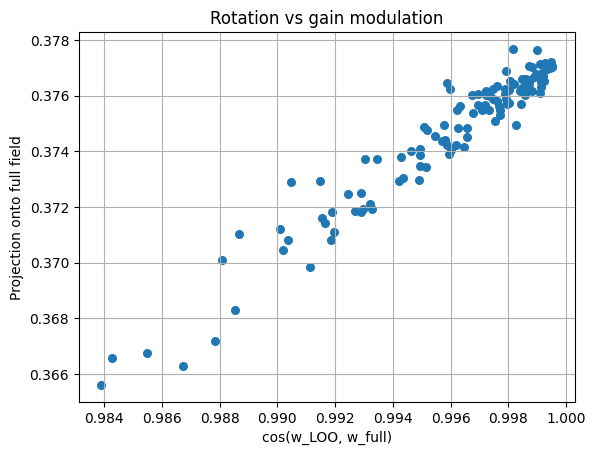

In [4]:
plt.figure()
plt.scatter(cos_to_full, proj, s=30)
plt.xlabel("cos(w_LOO, w_full)")
plt.ylabel("Projection onto full field")
plt.title("Rotation vs gain modulation")
plt.grid(True)
plt.show()


Animate mean ± std : 17.9079544049318 1.2323819248330798
Inanim mean ± std  : -20.512747764247695 1.7985675845273212
Separation (means) : 38.42070216917949


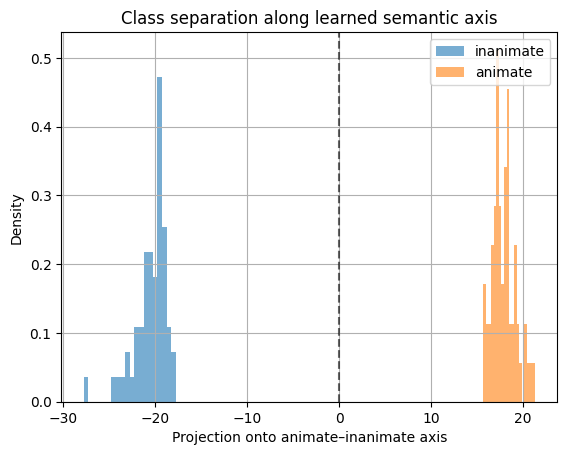

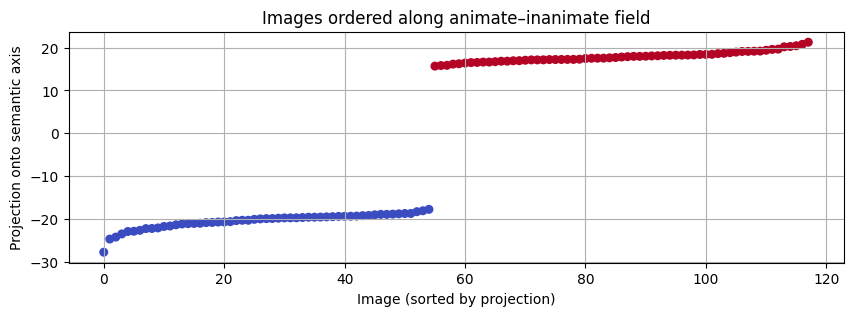

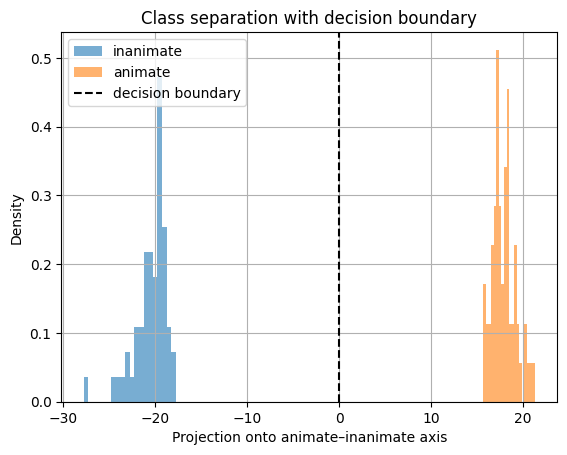

In [8]:
# ============================================================
# CLASS SEPARATION ALONG FULL FIELD
# ============================================================

# Unit semantic axis
w0 = w_full / np.linalg.norm(w_full)

# Scalar projection of each image
scores = X @ w0   # shape: (n_images,)

# Split by class
scores_anim = scores[y == 1]
scores_inan = scores[y == 0]

print("Animate mean ± std :", scores_anim.mean(), scores_anim.std())
print("Inanim mean ± std  :", scores_inan.mean(), scores_inan.std())
print("Separation (means) :", scores_anim.mean() - scores_inan.mean())
plt.figure()
plt.hist(scores_inan, bins=20, alpha=0.6, label="inanimate", density=True)
plt.hist(scores_anim, bins=20, alpha=0.6, label="animate", density=True)
plt.axvline(scores.mean(), color="k", linestyle="--", alpha=0.6)
plt.xlabel("Projection onto animate–inanimate axis")
plt.ylabel("Density")
plt.title("Class separation along learned semantic axis")
plt.legend()
plt.grid(True)
plt.show()

order = np.argsort(scores)

plt.figure(figsize=(10, 3))
plt.scatter(
    np.arange(n_images),
    scores[order],
    c=y[order],
    cmap="coolwarm",
    s=30
)
plt.xlabel("Image (sorted by projection)")
plt.ylabel("Projection onto semantic axis")
plt.title("Images ordered along animate–inanimate field")
plt.grid(True)
plt.show()

threshold = -b_full / np.linalg.norm(w_full)

plt.figure()
plt.hist(scores_inan, bins=20, alpha=0.6, label="inanimate", density=True)
plt.hist(scores_anim, bins=20, alpha=0.6, label="animate", density=True)
plt.axvline(threshold, color="k", linestyle="--", label="decision boundary")
plt.xlabel("Projection onto animate–inanimate axis")
plt.ylabel("Density")
plt.title("Class separation with decision boundary")
plt.legend()
plt.grid(True)
plt.show()


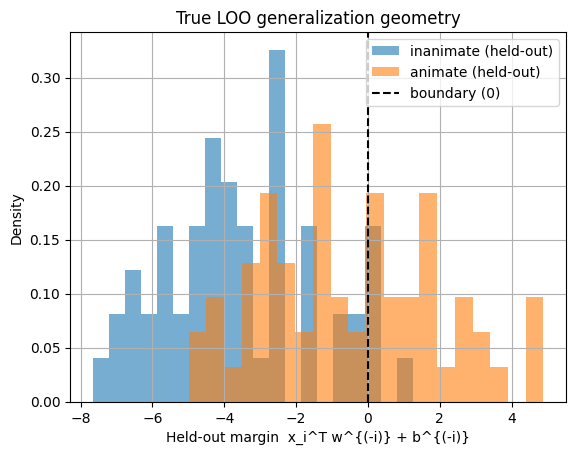

LOO accuracy: 0.652542372881356


In [10]:
# For each i, compute held-out margin under the model trained without i
heldout_margin = np.empty(n_images, dtype=np.float64)

for i in range(n_images):
    heldout_margin[i] = float(X[i] @ W[i].astype(np.float64) + B[i])

plt.figure()
plt.hist(heldout_margin[y==0], bins=20, alpha=0.6, density=True, label="inanimate (held-out)")
plt.hist(heldout_margin[y==1], bins=20, alpha=0.6, density=True, label="animate (held-out)")
plt.axvline(0.0, color="k", linestyle="--", label="boundary (0)")
plt.xlabel("Held-out margin  x_i^T w^{(-i)} + b^{(-i)}")
plt.ylabel("Density")
plt.title("True LOO generalization geometry")
plt.legend()
plt.grid(True)
plt.show()

loo_pred = (heldout_margin > 0).astype(int)
print("LOO accuracy:", (loo_pred == y).mean())


In [9]:
fisher_1d = (
    (scores_anim.mean() - scores_inan.mean())**2
    / (scores_anim.var() + scores_inan.var())
)

print("1D Fisher ratio along semantic axis:", fisher_1d)


1D Fisher ratio along semantic axis: 310.53245423879633


margins_full shape: (118,)
margins_loo shape : (118, 118)

Full model:
  min/mean/max margin: 5.922147365501653 7.209006480405595 10.467962458527452
  # misclassified (margin<0): 0
  # near-boundary |m|<1e-2: 0

LOO models (over all models+points):
  min/mean/max margin: -4.990437348139585 7.166693403456707 10.49758475031999
  fraction margin<0: 0.0029445561620224073


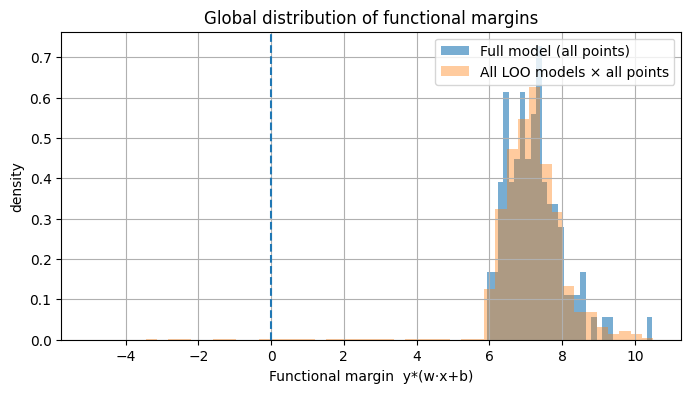

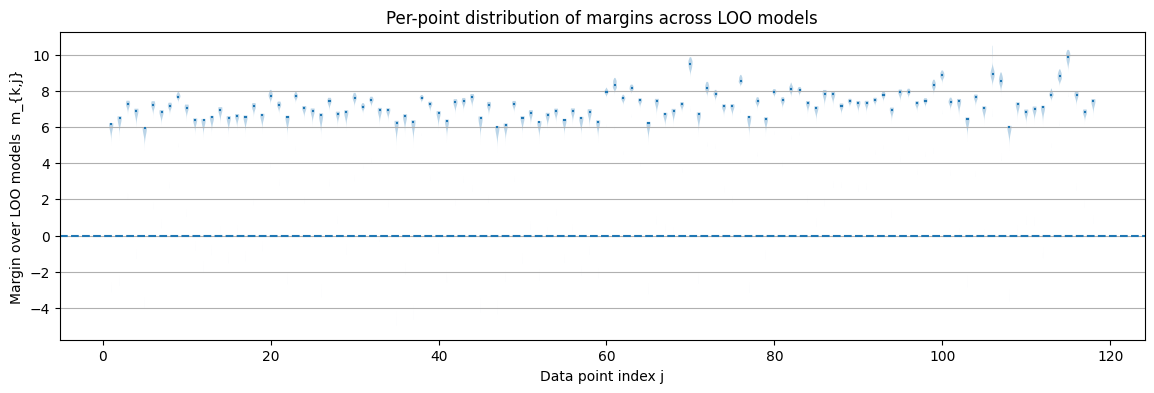

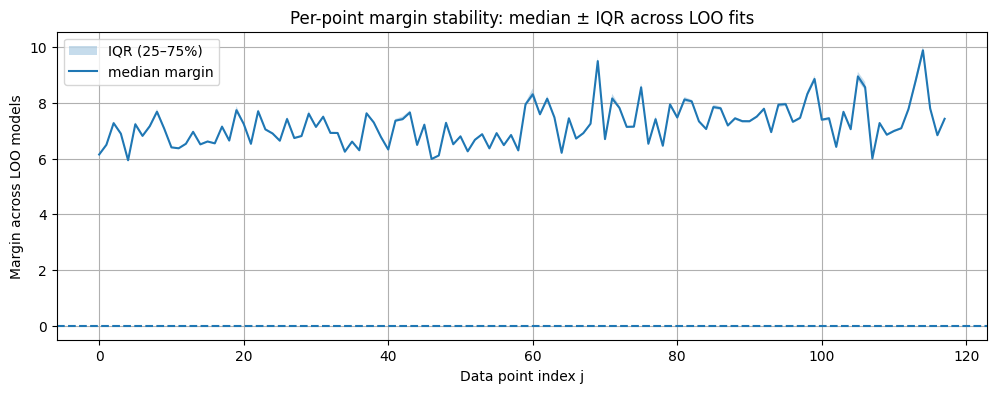

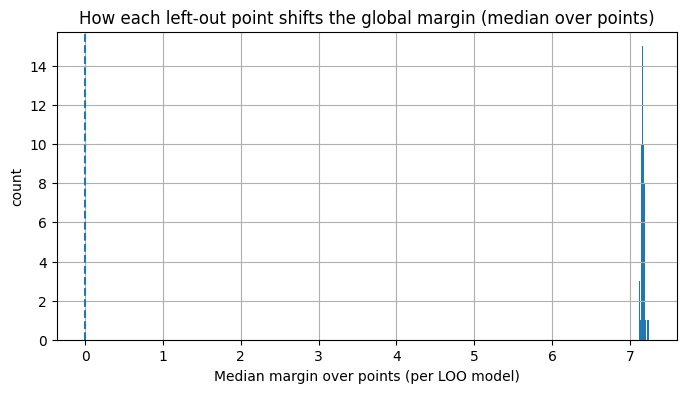

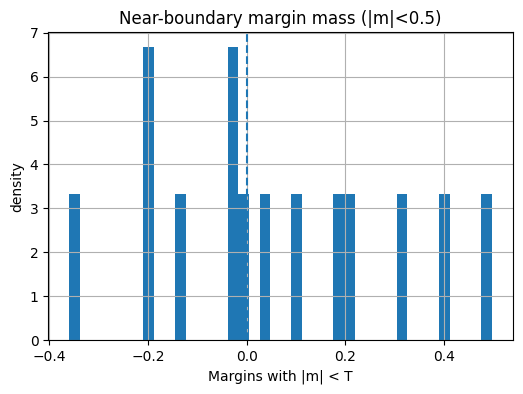

In [11]:
# ============================================================
# MARGINS: full model + all LOO models
# ============================================================

# Convert labels to {-1, +1} for signed margin
y_pm = (2 * y - 1).astype(np.float64)   # 0->-1, 1->+1

# Full model margins for all points
scores_full  = X @ w_full + b_full                     # (n_images,)
margins_full = y_pm * scores_full                      # (n_images,)

# LOO model margins for all points:
# scores_loo[k, j] = w_k^T x_j + b_k
# margins_loo[k, j] = y_j * score_loo[k, j]
scores_loo  = (W.astype(np.float64) @ X.T) + B.astype(np.float64)[:, None]   # (n_images, n_images)
margins_loo = scores_loo * y_pm[None, :]                                      # (n_images, n_images)

print("margins_full shape:", margins_full.shape)
print("margins_loo shape :", margins_loo.shape)

# Some useful summaries
print("\nFull model:")
print("  min/mean/max margin:", margins_full.min(), margins_full.mean(), margins_full.max())
print("  # misclassified (margin<0):", int((margins_full < 0).sum()))
print("  # near-boundary |m|<1e-2:", int((np.abs(margins_full) < 1e-2).sum()))

print("\nLOO models (over all models+points):")
print("  min/mean/max margin:", margins_loo.min(), margins_loo.mean(), margins_loo.max())
print("  fraction margin<0:", float((margins_loo < 0).mean()))

# ============================================================
# PLOT 1: Global margin distributions (full vs pooled LOO)
# ============================================================

plt.figure(figsize=(8,4))
plt.hist(margins_full, bins=30, alpha=0.6, density=True, label="Full model (all points)")
plt.hist(margins_loo.ravel(), bins=50, alpha=0.4, density=True, label="All LOO models × all points")
plt.axvline(0, linestyle="--")
plt.xlabel("Functional margin  y*(w·x+b)")
plt.ylabel("density")
plt.title("Global distribution of functional margins")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# PLOT 2: Per-point margin distribution across LOO models
# (Each data point j has a distribution over k = left-out index)
# ============================================================

# Option A: Violin plot (readable for ~118 points)
plt.figure(figsize=(14,4))
plt.violinplot(margins_loo, showmeans=False, showmedians=True, showextrema=False)
plt.axhline(0, linestyle="--")
plt.xlabel("Data point index j")
plt.ylabel("Margin over LOO models  m_{k,j}")
plt.title("Per-point distribution of margins across LOO models")
plt.grid(True, axis="y")
plt.show()

# Option B: Show uncertainty band per point (median ± IQR)
med = np.median(margins_loo, axis=0)
q25 = np.percentile(margins_loo, 25, axis=0)
q75 = np.percentile(margins_loo, 75, axis=0)

plt.figure(figsize=(12,4))
xs = np.arange(n_images)
plt.fill_between(xs, q25, q75, alpha=0.25, label="IQR (25–75%)")
plt.plot(xs, med, linewidth=1.5, label="median margin")
plt.axhline(0, linestyle="--")
plt.xlabel("Data point index j")
plt.ylabel("Margin across LOO models")
plt.title("Per-point margin stability: median ± IQR across LOO fits")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# PLOT 3: "Leave-one-out influence" as a distribution shift
# For each LOO model k, look at distribution over j
# ============================================================

# Summarize each LOO model by its median margin over points
loo_med_by_model = np.median(margins_loo, axis=1)

plt.figure(figsize=(8,4))
plt.hist(loo_med_by_model, bins=25)
plt.axvline(0, linestyle="--")
plt.xlabel("Median margin over points (per LOO model)")
plt.ylabel("count")
plt.title("How each left-out point shifts the global margin (median over points)")
plt.grid(True)
plt.show()

# ============================================================
# OPTIONAL: zoom in on the "thermal" region near the boundary
# ============================================================

T = 0.5  # pick a scale that feels like "temperature" for your standardized X
near = np.abs(margins_loo) < T
plt.figure(figsize=(6,4))
plt.hist(margins_loo[near], bins=40, density=True)
plt.axvline(0, linestyle="--")
plt.xlabel("Margins with |m| < T")
plt.ylabel("density")
plt.title(f"Near-boundary margin mass (|m|<{T})")
plt.grid(True)
plt.show()


In [12]:
# Compare margins difference pointwise
delta = margins_loo - margins_full[None, :]

print("Mean |Δmargin|:", np.mean(np.abs(delta)))
print("Max  |Δmargin|:", np.max(np.abs(delta)))
print("Fraction where sign changes:",
      np.mean(np.sign(margins_loo) != np.sign(margins_full[None, :])))


Mean |Δmargin|: 0.11477781610528975
Max  |Δmargin|: 11.222804840652033
Fraction where sign changes: 0.0029445561620224073


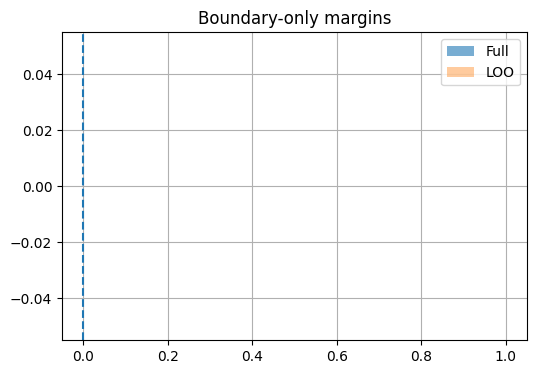

In [13]:
# Focus only on boundary points
boundary = np.abs(margins_full) < 1.0

plt.figure(figsize=(6,4))
plt.hist(margins_full[boundary], bins=30, alpha=0.6, label="Full")
plt.hist(margins_loo[:, boundary].ravel(), bins=50, alpha=0.4, label="LOO")
plt.axvline(0, linestyle="--")
plt.legend()
plt.title("Boundary-only margins")
plt.grid(True)
plt.show()


In [14]:
# ============================================================
# BOUNDARY DIAGNOSTICS PER IMAGE
# ============================================================

# 1. Full-model margin
m_full = margins_full                     # (n_images,)

# 2. LOO statistics per image j
m_loo_mean = margins_loo.mean(axis=0)
m_loo_std  = margins_loo.std(axis=0)

# 3. Sign-flip rate per image
sign_full = np.sign(m_full)
sign_loo  = np.sign(margins_loo)
flip_rate = np.mean(sign_loo != sign_full[None, :], axis=0)

# 4. Pack everything into a table-like structure
boundary_stats = {
    "index": np.arange(n_images),
    "margin_full": m_full,
    "loo_std": m_loo_std,
    "flip_rate": flip_rate,
}

# Sortings for inspection
idx_small_margin = np.argsort(np.abs(m_full))
idx_high_var     = np.argsort(-m_loo_std)
idx_flip         = np.argsort(-flip_rate)

print("\nTop boundary images by |full margin|:")
for i in idx_small_margin[:10]:
    print(i, "margin=", m_full[i], "flip_rate=", flip_rate[i], "std=", m_loo_std[i])

print("\nTop boundary images by LOO flip rate:")
for i in idx_flip[:10]:
    print(i, "flip_rate=", flip_rate[i], "margin=", m_full[i], "std=", m_loo_std[i])

print("\nTop boundary images by LOO variance:")
for i in idx_high_var[:10]:
    print(i, "std=", m_loo_std[i], "margin=", m_full[i], "flip_rate=", flip_rate[i])



Top boundary images by |full margin|:
4 margin= 5.922147365501653 flip_rate= 0.00847457627118644 std= 0.9170416943183769
46 margin= 5.97250050424357 flip_rate= 0.00847457627118644 std= 0.9482125068129141
107 margin= 5.990543064153157 flip_rate= 0.00847457627118644 std= 0.8861322297932008
47 margin= 6.098126081787042 flip_rate= 0.00847457627118644 std= 0.7969883177743634
0 margin= 6.130358895757138 flip_rate= 0.00847457627118644 std= 0.8524752806985201
64 margin= 6.1905311678302875 flip_rate= 0.00847457627118644 std= 0.8677337863031612
34 margin= 6.232367492512449 flip_rate= 0.00847457627118644 std= 1.0308822904844779
51 margin= 6.2455514195800115 flip_rate= 0.00847457627118644 std= 0.8046926356807131
36 margin= 6.275689551624945 flip_rate= 0.00847457627118644 std= 1.0037497754625642
58 margin= 6.27909218606505 flip_rate= 0.00847457627118644 std= 0.7951828277946271

Top boundary images by LOO flip rate:
0 flip_rate= 0.00847457627118644 margin= 6.130358895757138 std= 0.8524752806985201


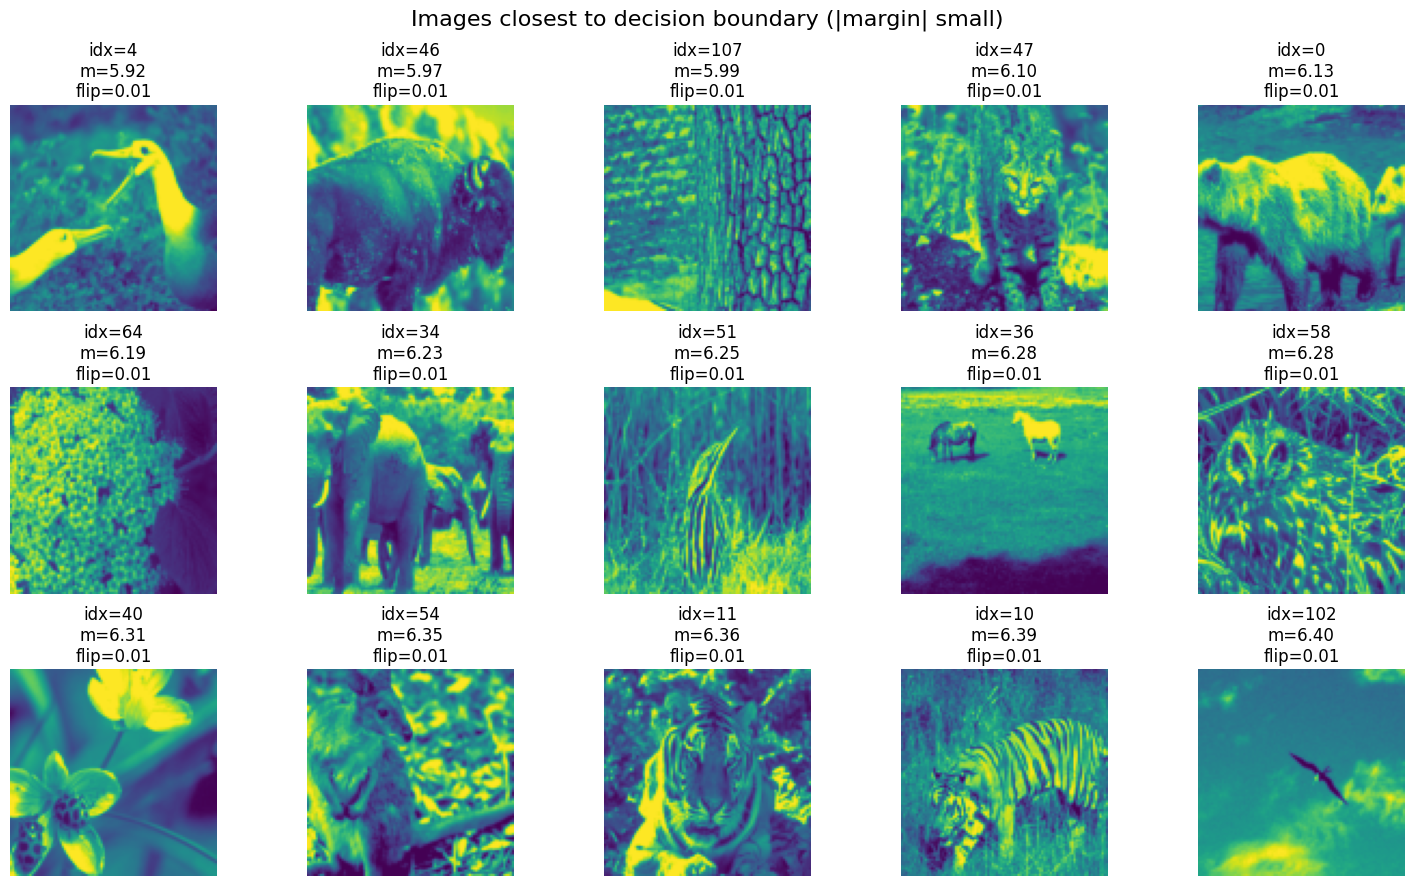

In [15]:
from PIL import Image
import os

IMG_DIR = "/home/maria/ProjectionSort/data/images/images"

def load_img(idx):
    fname = f"scene_{idx:03d}.png"
    path = os.path.join(IMG_DIR, fname)
    return Image.open(path)

def plot_images(indices, title, ncols=5):
    n = len(indices)
    nrows = int(np.ceil(n / ncols))

    plt.figure(figsize=(3*ncols, 3*nrows))
    for k, idx in enumerate(indices):
        plt.subplot(nrows, ncols, k+1)
        plt.imshow(load_img(idx))
        plt.axis("off")
        plt.title(
            f"idx={idx}\n"
            f"m={m_full[idx]:.2f}\n"
            f"flip={flip_rate[idx]:.2f}"
        )
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

# Closest to boundary
plot_images(
    idx_small_margin[:15],
    title="Images closest to decision boundary (|margin| small)"
)


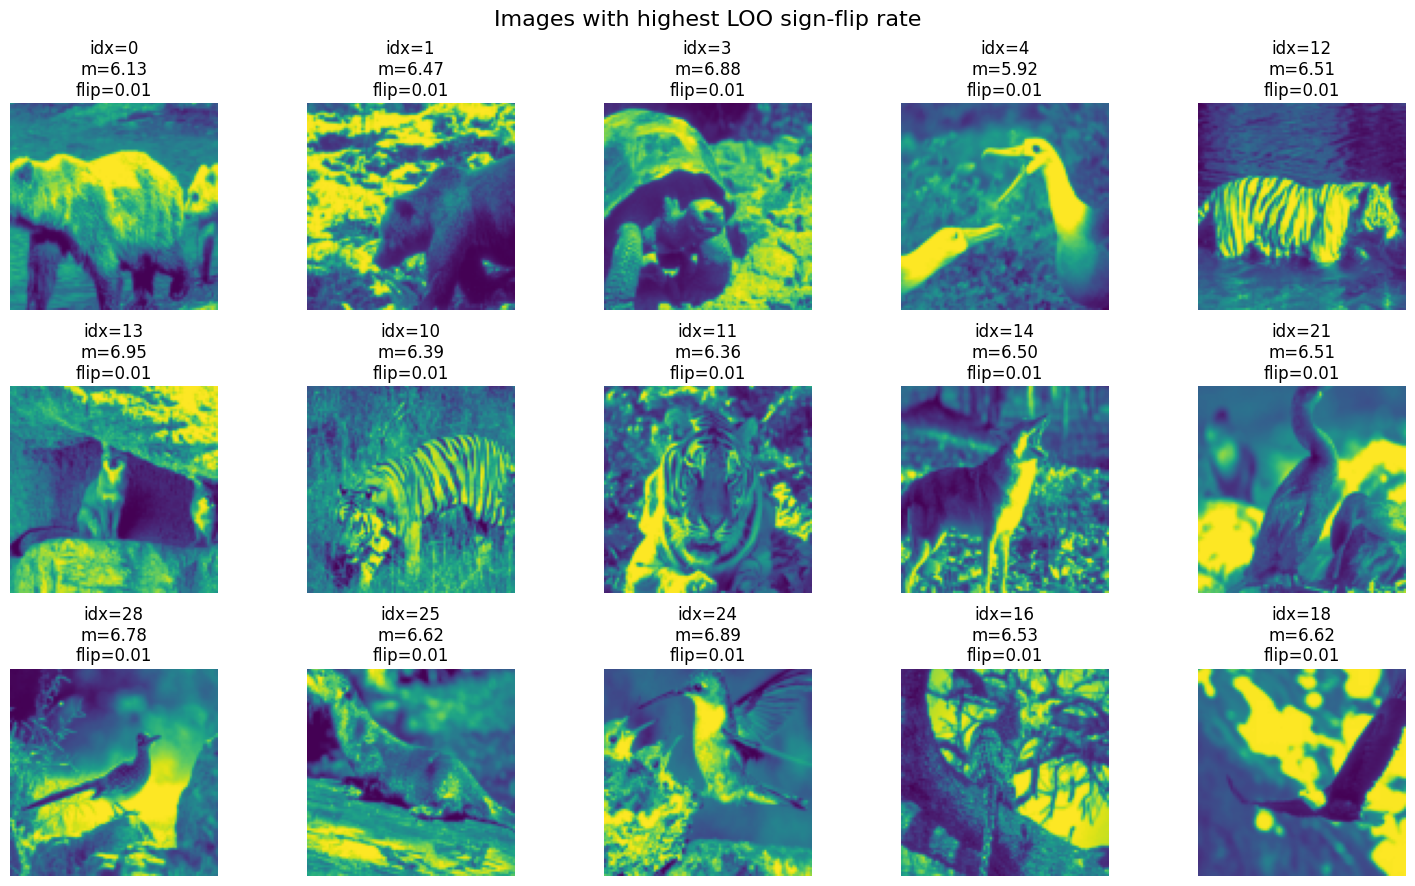

In [16]:
plot_images(
    idx_flip[:15],
    title="Images with highest LOO sign-flip rate"
)


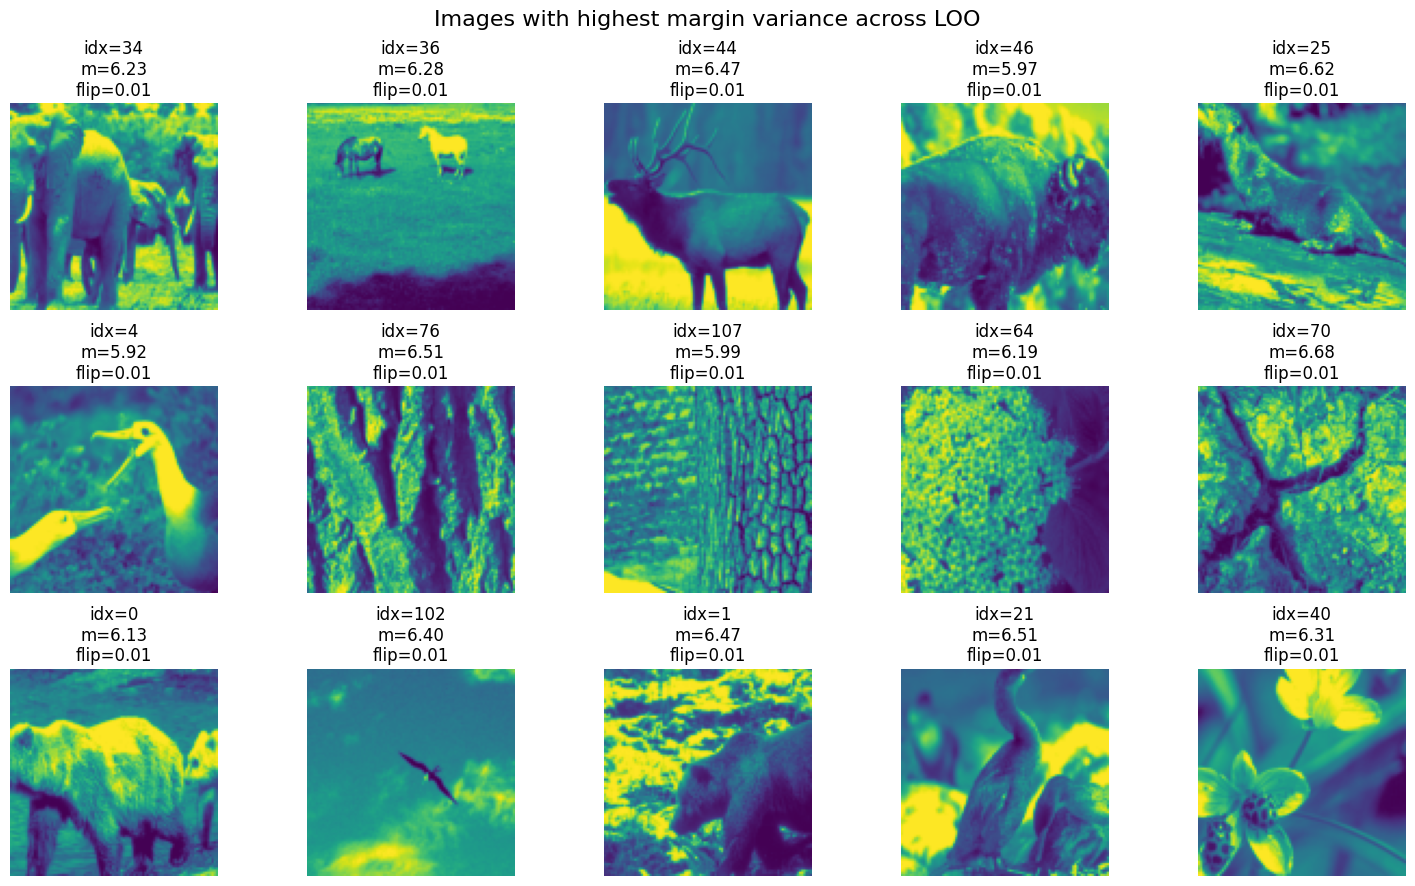

In [17]:
plot_images(
    idx_high_var[:15],
    title="Images with highest margin variance across LOO"
)
